In [32]:
!pip install kaggle
!kaggle datasets download -d kartik2112/fraud-detection
!unzip fraud-detection.zip

Dataset URL: https://www.kaggle.com/datasets/kartik2112/fraud-detection
License(s): CC0-1.0
fraud-detection.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  fraud-detection.zip
replace fraudTest.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace fraudTrain.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [33]:
import pandas as pd
train = pd.read_csv("fraudTrain.csv")
test = pd.read_csv("fraudTest.csv")

In [34]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (1296675, 23)
Test shape: (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [35]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [36]:
# check duplicates
train.duplicated().sum()

np.int64(0)

In [37]:
# class imbalance
train["is_fraud"].value_counts()

,count
is_fraud,
0,1289169
1,7506


In [59]:
train["is_fraud"].value_counts(normalize=True) * 100

,proportion
is_fraud,
0,99.421135
1,0.578865


# **EDA**

In [39]:
# remove Unnamed column
train = train.drop(columns=["Unnamed: 0"])
test = test.drop(columns=["Unnamed: 0"])

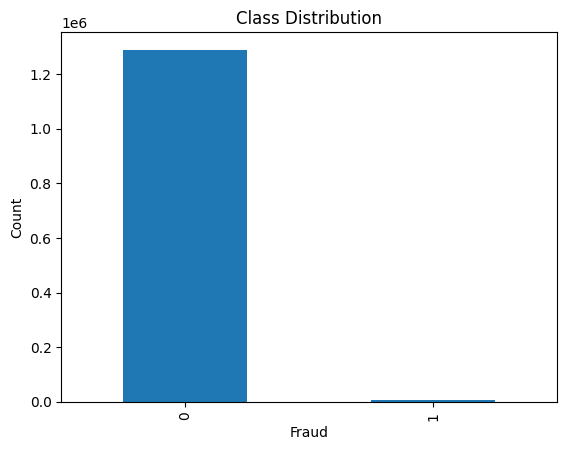

In [40]:
# class distribution
import matplotlib.pyplot as plt
train["is_fraud"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Fraud")
plt.ylabel("Count")
plt.show()

#### Analyze transaction amount

In [41]:
train["amt"].describe()

,amt
count,1.296675e+06
mean,7.035104e+01
std,1.603160e+02
min,1.000000e+00
25%,9.650000e+00
50%,4.752000e+01
75%,8.314000e+01
max,2.894890e+04


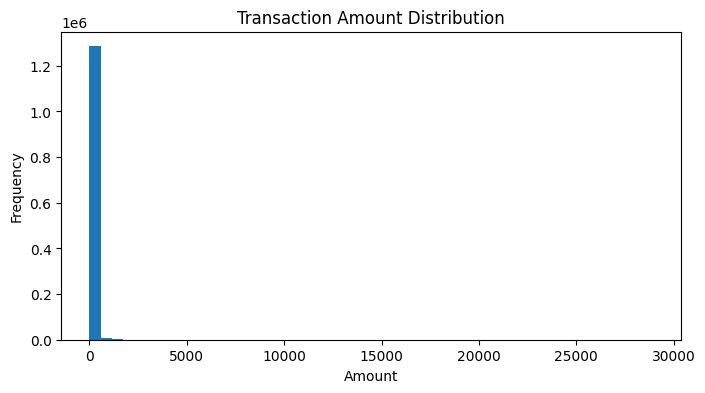

In [42]:
plt.figure(figsize=(8,4))
plt.hist(train["amt"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

In [61]:
# fraud vs amount
train.groupby("is_fraud")["amt"].median()

,amt
is_fraud,
0,47.280
1,396.505


In [44]:
# merchant categories
fraud_only = train[train["is_fraud"] == 1]
fraud_only["category"].value_counts().head(10)

,count
category,
grocery_pos,1743
shopping_net,1713
misc_net,915
shopping_pos,843
gas_transport,618
misc_pos,250
kids_pets,239
entertainment,233
personal_care,220


#### Time features

In [45]:
train["trans_date_trans_time"] = pd.to_datetime(train["trans_date_trans_time"])

In [46]:
train["hour"] = train["trans_date_trans_time"].dt.hour

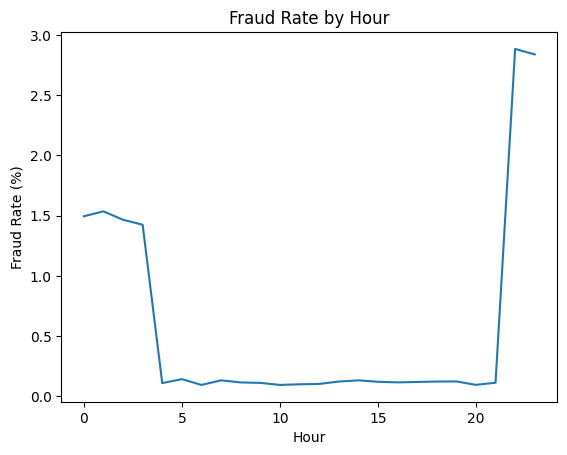

In [60]:
fraud_rate_by_hour = train.groupby("hour")["is_fraud"].mean() * 100
fraud_rate_by_hour.plot()
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.show()

# **Feature Engineering**

In [48]:
# cutomer age
train["dob"] = pd.to_datetime(train["dob"])

In [49]:
train["customer_age"] = (train["trans_date_trans_time"].dt.year - train["dob"].dt.year)

In [50]:
train["customer_age"].describe()

,customer_age
count,1.296675e+06
mean,4.602930e+01
std,1.738237e+01
min,1.400000e+01
25%,3.300000e+01
50%,4.400000e+01
75%,5.700000e+01
max,9.600000e+01


In [51]:
# weekday
train["weekday"] = train["trans_date_trans_time"].dt.weekday

In [52]:
# weekend feature
train["is_weekend"] = train["weekday"].isin([5,6]).astype(int)

In [53]:
# distance feature
import numpy as np
train["distance"] = np.sqrt((train["lat"] - train["merch_lat"])**2 + (train["long"] - train["merch_long"])**2)

In [54]:
train["distance"].describe()

,distance
count,1.296675e+06
mean,7.656611e-01
std,2.847484e-01
min,2.386629e-04
25%,5.649579e-01
50%,7.983111e-01
75%,9.775357e-01
max,1.413364e+00


In [55]:
# drop useless columns
cols_to_drop = ["first", "last", "street", "trans_num", "dob","trans_date_trans_time"]
train = train.drop(columns=cols_to_drop)

In [56]:
train.columns

Index(['cc_num', 'merchant', 'category', 'amt', 'gender', 'city', 'state',
       'zip', 'lat', 'long', 'city_pop', 'job', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'hour', 'customer_age', 'weekday',
       'is_weekend', 'distance'],
      dtype='object')

In [62]:
train = train.drop(columns=["cc_num"])

#### encoding

In [63]:
from sklearn.preprocessing import LabelEncoder

In [64]:
train.dtypes

,0
merchant,object
category,object
amt,float64
gender,object
city,object
state,object
zip,int64
lat,float64
long,float64
city_pop,int64


In [66]:
categorical_cols = ["merchant", "category", "gender", "city", "state", "job"]

In [67]:
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    encoders[col] = le

In [68]:
X = train.drop(columns=["is_fraud"])
y = train["is_fraud"]

In [69]:
X.shape, y.shape

((1296675, 19), (1296675,))

In [70]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [71]:
y_train.value_counts()

,count
is_fraud,
0,1031335
1,6005


In [72]:
scale_pos_weight = 1031335 / 6005
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
scale_pos_weight

np.float64(171.74604496253122)

In [73]:
!pip install xgboost

In [75]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

In [76]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [77]:
y_pred = xgb_model.predict(X_val)

In [78]:
y_prob = xgb_model.predict_proba(X_val)[:, 1]

In [79]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [80]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.70      0.94      0.80      1501

    accuracy                           1.00    259335
   macro avg       0.85      0.97      0.90    259335
weighted avg       1.00      1.00      1.00    259335



In [81]:
confusion_matrix(y_val, y_pred)

array([[257217,    617],
       [    86,   1415]])

In [82]:
roc_auc = roc_auc_score(y_val, y_prob)
print(roc_auc)

0.9992380393570035


In [84]:
# feature importance
import pandas as pd

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(15)

,feature,importance
2,amt,0.433201
14,hour,0.204972
1,category,0.136156
3,gender,0.032058
15,customer_age,0.029364
9,city_pop,0.018144
5,state,0.012957
7,lat,0.012645
8,long,0.012644
6,zip,0.012373


In [85]:
!pip install shap

In [86]:
import shap

In [87]:
explainer = shap.TreeExplainer(xgb_model)

In [88]:
sample = X_val.sample(200, random_state=42)

In [89]:
shap_values = explainer.shap_values(sample)

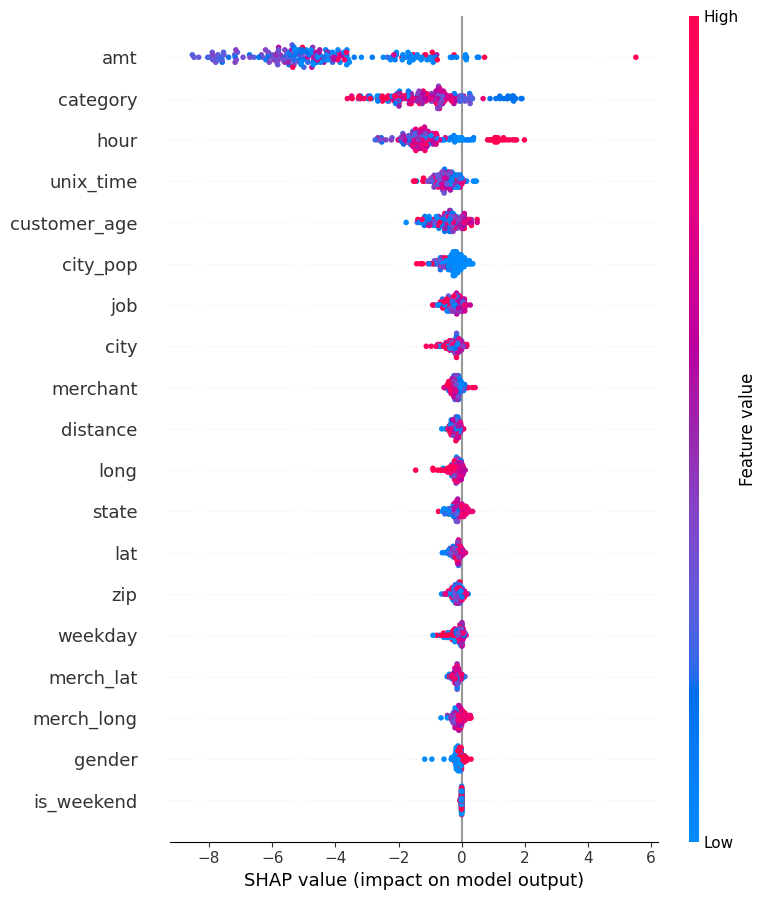

In [90]:
shap.summary_plot(shap_values, sample)

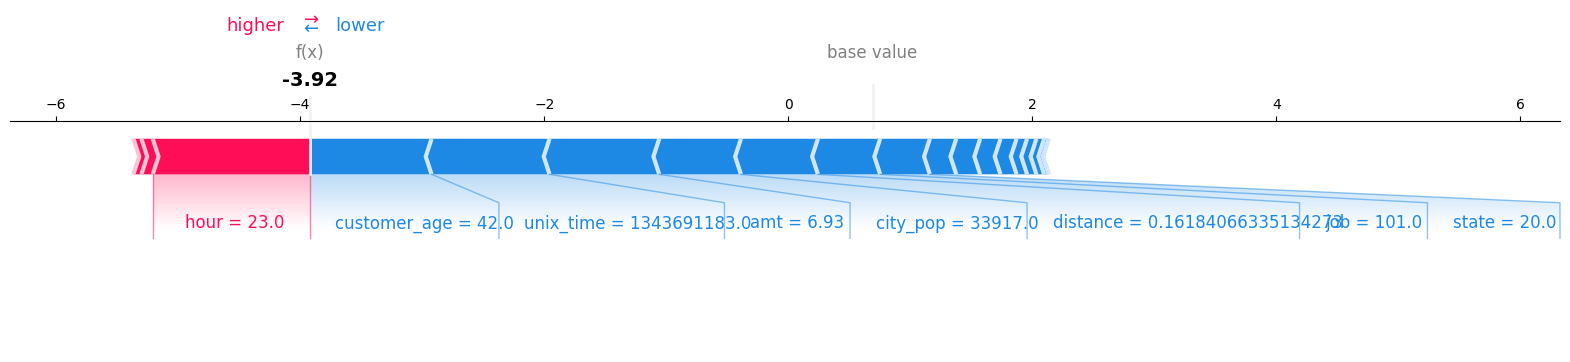

In [91]:
sample.iloc[0]
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    sample.iloc[0],
    matplotlib=True
)

In [92]:
def explain_any_transaction(index, X_data, model, explainer):
    transaction = X_data.iloc[[index]]

    prob = model.predict_proba(transaction)[0][1]
    shap_values = explainer.shap_values(transaction)

    feature_names = transaction.columns
    values = transaction.iloc[0].values
    shap_vals = shap_values[0]

    contributions = list(zip(feature_names, values, shap_vals))
    contributions = sorted(contributions, key=lambda x: abs(x[2]), reverse=True)

    if prob >= 0.70:
        risk = "HIGH"
        decision = "Block or Manual Review"
    elif prob >= 0.30:
        risk = "MEDIUM"
        decision = "Manual Review"
    else:
        risk = "LOW"
        decision = "Approve"

    print("=" * 50)
    print(f"Transaction Index: {index}")
    print(f"Fraud Probability: {prob:.2%}")
    print(f"Risk Level: {risk}")
    print(f"Recommended Action: {decision}")
    print("\nMain Reasons:")

    for feature, value, impact in contributions[:5]:
        direction = "increased" if impact > 0 else "reduced"
        print(f"- {feature} = {value} {direction} fraud risk")

    print("=" * 50)

In [93]:
explain_any_transaction(0, X_val, xgb_model, explainer)

Transaction Index: 0
Fraud Probability: 0.07%
Risk Level: LOW
Recommended Action: Approve

Main Reasons:
- category = 8.0 reduced fraud risk
- amt = 6.64 reduced fraud risk
- hour = 3.0 reduced fraud risk
- customer_age = 66.0 reduced fraud risk
- unix_time = 1367207861.0 reduced fraud risk


In [94]:
fraud_indices = [i for i, pred in enumerate(y_pred) if pred == 1]
fraud_indices[:5]

[190, 210, 230, 303, 415]

In [95]:
explain_any_transaction(fraud_indices[0], X_val, xgb_model, explainer)

Transaction Index: 190
Fraud Probability: 100.00%
Risk Level: HIGH
Recommended Action: Block or Manual Review

Main Reasons:
- amt = 1006.4 increased fraud risk
- hour = 22.0 increased fraud risk
- customer_age = 80.0 increased fraud risk
- category = 11.0 reduced fraud risk
- city_pop = 145.0 increased fraud risk


#### dashboard

In [96]:
import joblib

In [97]:
joblib.dump(xgb_model, "fraud_model.pkl")
joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']